/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/954 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/36 [00:00<?, ?it/s]

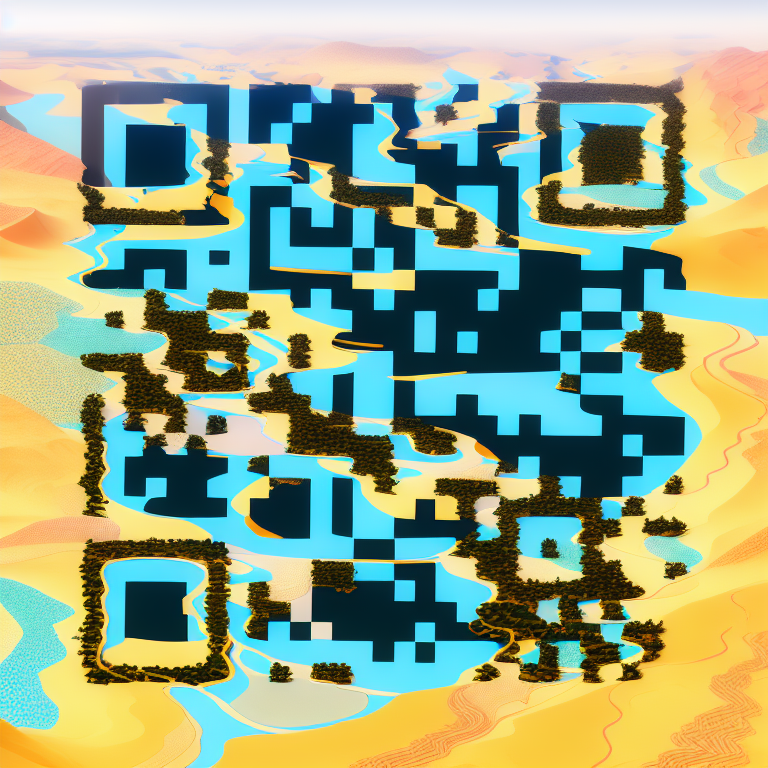

In [2]:
#!pip -q install diffusers transformers accelerate torch xformers qrcode

from qr_art import generate_qr_art
from IPython.display import display
from google.colab import files
from PIL import Image
riyadh_image = '/content/riyadh-skyline.webp'
init_image = riyadh_image
# base description
base_prompt = "A sky view of sahara red sand winding through a golden desert, saudi arabia"

# all extra descriptors, grouped but kept flat for easy joining
descriptors = [
    # Perspective & Framing
    "aerial perspective", "bird’s‑eye view", "top‑down shot", "high‑altitude drone photo", "wide panorama",
    # Primary Subjects
    "multicoloured buildings", "large highways", "braided channels", "golden sand dunes",
    "rippled desert floor", "sparse desert shrubs",
    # Colour Palette
    "saudi national colours", "emerald green"]
    #, #"sapphire blue", "ruby red", "amber orange",
    # "magenta accents", "golden‑ochre sand", "high saturation", "complementary contrast",
    # # Lighting & Time
    # "midday sun", "bright overhead light", "warm golden‑hour glow", "crisp shadows",
    # "high‑contrast illumination",
    # # Mood & Atmosphere
    # "surreal", "dreamlike", "tranquil", "majestic", "other‑worldly",
    # # Style & Rendering
    # "hyper‑realistic", "cinematic", "photorealistic", "8K resolution", "HDR",
    # "ultra‑detailed", "volumetric lighting",
    # # Camera & Lens
    # "wide‑angle lens", "35 mm equivalent", "f/4 aperture", "high shutter speed",
    # "ISO 100", "drone camera",
    # # Composition & Geometry
    # "leading lines", "winding curves", "organic patterns", "rule of thirds",
    # "diagonal flow", "negative space",
    # # Textures & Details
    # "fine sand ripples", "shimmering water surface", "subtle reflections", "grain‑free clarity",
    # # Optional Enhancements
    # "tilt‑shift effect", "panoramic 16:9 aspect", "symmetrical composition",
    # "minimal cloud haze", "no people", "clean horizon"
# ]
# core negatives
base_neg_prompt = "ugly, disfigured, low quality, blurry, nsfw"

# extra blockers – grouped but flat for easy joining
extra_neg = [
    # Technical flaws
    "lowres", "pixelated", "grainy", "noise", "jpeg artifacts", "out of focus",
    "motion blur", "camera shake", "chromatic aberration", "overexposed", "underexposed",
    "harsh shadows", "lens flare", "washed out", "oversaturated",
    # Composition issues
    "cropped", "cut off", "out of frame", "tilted horizon", "wrong perspective",
    # Dupes & distortions
    "duplicate", "mirrored", "cloned", "overlapping", "mutated", "deformed", "distorted",
    "bad anatomy", "extra limbs", "missing limbs",
    # Unwanted content
    "text", "logo", "watermark", "signature", "border",
    # Style mismatches
    "cartoon", "anime", "3d render", "cgi", "low poly",
    # Content bans
    "gore", "blood", "violence", "nudity"
]


# --- Inputs ---------------------------------------------------------------
qr_content  = "https://works.estebanvalencia.com"      # data encoded in the QR
img_prompt = f"{base_prompt}, " + ", ".join(descriptors)  # what you want to see
neg_prompt  = "ugly, disfigured, low quality, blurry, nsfw"   # stuff to push away from

# --- Generation knobs -----------------------------------------------------
guidance_scale               = 7.5   # ↑ = obey text prompt more, ↓ = keep SD’s prior creativity
controlnet_conditioning_scale = 1.8   # ↑ = preserve QR pattern more, ↓ = allow heavier stylisation
strength                     = 0.9   # 0 → copy QR exactly, 1 → full redraw; 0.8‑0.95 is the sweet spot
sampler                      = "DPM++ Karras SDE"  # diffusion scheduler (trade‑off speed vs. quality)
seed                         = 5392011833          # set for repeatability, None for random each run

img = generate_qr_art(
    init_image = init_image,
    qr_code_content = qr_content,
    prompt          = img_prompt,
    negative_prompt = neg_prompt,
    guidance_scale  =  guidance_scale,
    controlnet_conditioning_scale = controlnet_conditioning_scale,
    strength        = strength,
    sampler         = sampler,
    seed            = seed,
)
display(img)
